In [1]:
import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

## Simulating data
We are simulating thirty trials assuming 82% correct for full attention condition and 72% for poor attention condition.

In [19]:
# Set parameters and random seed
trials_n = 30
np.random.seed(1974)

# Create DataFrame
example03_df = pd.DataFrame(
    {
        "Attention": pd.Categorical(
            ["Full"] * trials_n + ["Poor"] * trials_n, categories=["Poor", "Full"]
        ),
        "Correct": np.concatenate(
            [
                np.random.binomial(n=1, p=0.82, size=trials_n),
                np.random.binomial(n=1, p=0.72, size=trials_n),
            ]
        ),
    }
)

# Group by Attention and calculate mean Correct
example03_avg = (
    example03_df.groupby("Attention")["Correct"]
    .agg(Pcorrect="mean")
    .reset_index()
)

print(example03_avg)

  Attention  Pcorrect
0      Poor  0.700000
1      Full  0.833333


## Model definition: difference as parameter

$$Correct \sim Bernoulli(p_i)$$
$$logit(p_i) = \alpha_{poor} + \beta_{A} IsFull_i$$

$$\alpha_{poor} \sim Normal(logit(0.75), 0.5)$$
$$\beta_A \sim Normal(0, 1)$$

## Compiling the model

In [21]:
example03_model = cmdstanpy.CmdStanModel(stan_file="Stan/example03-via-difference.stan")

## Preparing the data in Stan format

In [22]:
example03_standata = {
    "N": len(example03_df),
    "AttentionN": len(example03_df["Attention"].cat.categories),
    "Correct": example03_df["Correct"].to_numpy(),
    "Attention": example03_df["Attention"].cat.codes.to_numpy() + 1,
}

{'N': 60,
 'AttentionN': 2,
 'Correct': array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
        1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32),
 'Attention': array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int8)}

## Sampling the model

In [23]:
example03_fit = example03_model.sample(
    data=example03_standata,
    chains=4,
    parallel_chains=os.cpu_count())

17:17:40 - cmdstanpy - INFO - Requested 8 parallel_chains but only 4 required, will run all chains in parallel.
17:17:41 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

17:17:41 - cmdstanpy - INFO - CmdStan done processing.


## Extracting samples

In [24]:
example03_samples = example03_fit.draws_pd()

## Plot posterior distribution for estimated proportion of correct responses per condition

In [29]:
# Melt wide pCorrect columns into long format
posterior_pcorrect = (
    example03_samples.filter(like="pCorrect")
    .assign(draw__=example03_samples["draw__"])
    .melt(
        id_vars=["draw__"],
        var_name="Attention",
        value_name="Pcorrect",
    )
)

# Map pCorrect column names to category names ('Poor', 'Full')
# Aligning with the original categories from example03_df
attention_labels = example03_df["Attention"].cat.categories.tolist()
posterior_pcorrect["Attention"] = pd.Categorical(
    posterior_pcorrect["Attention"].map(
        dict(zip(posterior_pcorrect["Attention"].unique(), attention_labels))
    ),
    categories=attention_labels,
    ordered=True,
)

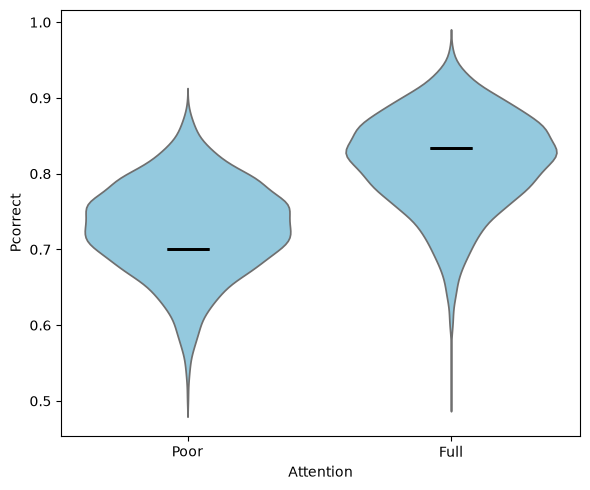

In [30]:
# Plotting with Seaborn and Matplotlib
plt.figure(figsize=(6, 5))

# Violin plot of posterior draws
sns.violinplot(
    data=posterior_pcorrect,
    x="Attention",
    y="Pcorrect",
    inner=None,
    color="skyblue",
)

# Overlay sample mean reference lines using errorbar/scatter
plt.errorbar(
    x=example03_avg["Attention"].astype(str),
    y=example03_avg["Pcorrect"],
    yerr=0,
    fmt="none",
    ecolor="black",
    capsize=15,
    capthick=2,
    linewidth=0,
)

plt.ylabel("Pcorrect")
plt.tight_layout()
plt.show()

## Plot posterior distribution for estimated difference in log-odds (b_A)

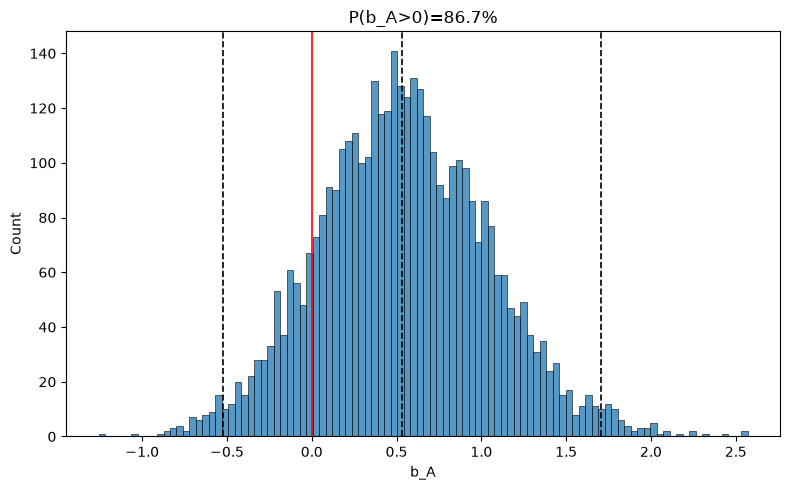

In [35]:
# compute 97% credible interval + median
b_A_quantiles = np.quantile(example03_samples["b_A"], [(1 - 0.97) / 2, 0.5, 1 - (1 - 0.97) / 2])

# plot posterior distribution for probability of correct response
plt.figure(figsize=(8, 5))
sns.histplot(example03_samples["b_A"], bins=100, stat="count")
for x in b_A_quantiles:
    plt.axvline(x, color="black", linestyle="--", linewidth=1.2)
plt.axvline(0, color="red", linestyle="-", linewidth=1.2)

plt.xlabel("b_A")
plt.ylabel("Count")
plt.title("P(b_A>0)=%.1f%%"%(100 * np.mean(example03_samples['b_A'] > 0)))
plt.tight_layout()
plt.show()

## Plot posterior distribution for estimated difference in units of probability

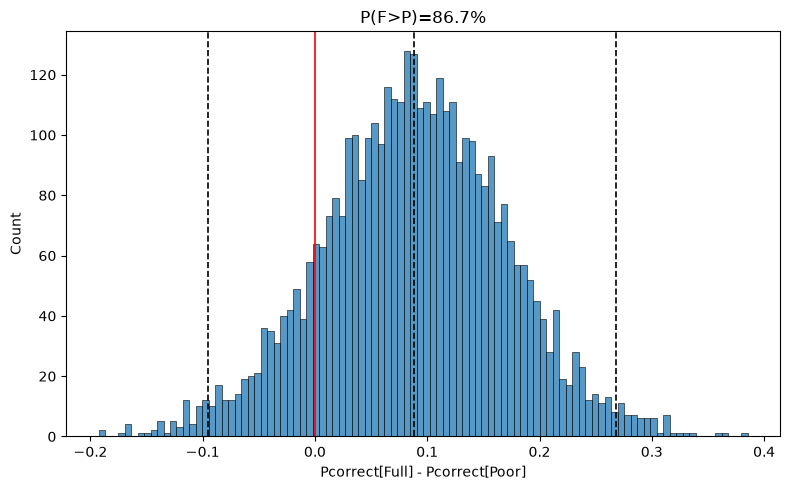

In [36]:
# compute 97% credible interval + median
dA_quantiles = np.quantile(example03_samples["dA"], [(1 - 0.97) / 2, 0.5, 1 - (1 - 0.97) / 2])

# plot posterior distribution for probability of correct response
plt.figure(figsize=(8, 5))
sns.histplot(example03_samples["dA"], bins=100, stat="count")
for x in dA_quantiles:
    plt.axvline(x, color="black", linestyle="--", linewidth=1.2)
plt.axvline(0, color="red", linestyle="-", linewidth=1.2)

plt.xlabel("Pcorrect[Full] - Pcorrect[Poor]")
plt.ylabel("Count")
plt.title("P(F>P)=%.1f%%"%(100 * np.mean(example03_samples['dA'] > 0)))
plt.tight_layout()
plt.show()

## Same model but via indexing approach

$$Correct \sim Bernoulli(p_i)$$
$$p_i = p_{correct}[Attention_i]$$

$$p_{correct} \sim BetaProportion(0.75, 5)$$

Compiling the model

In [37]:
example03_indexing_model = cmdstanpy.CmdStanModel(stan_file="Stan/example03-via-indexing.stan")

Sampling

In [38]:
example03_indexing_fit = example03_indexing_model.sample(
    data=example03_standata,
    chains=4,
    parallel_chains=os.cpu_count())

17:29:46 - cmdstanpy - INFO - Requested 8 parallel_chains but only 4 required, will run all chains in parallel.
17:29:46 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

17:29:47 - cmdstanpy - INFO - CmdStan done processing.


Extracting samples

In [40]:
example03_indexing_samples = example03_indexing_fit.draws_pd()

Plot posterior distribution for estimated proportion of correct responses per condition

In [41]:
# Melt wide pCorrect columns into long format
posterior_pcorrect = (
    example03_indexing_samples.filter(like="pCorrect")
    .assign(draw__=example03_indexing_samples["draw__"])
    .melt(
        id_vars=["draw__"],
        var_name="Attention",
        value_name="Pcorrect",
    )
)

# Map pCorrect column names to category names ('Poor', 'Full')
# Aligning with the original categories from example03_df
attention_labels = example03_df["Attention"].cat.categories.tolist()
posterior_pcorrect["Attention"] = pd.Categorical(
    posterior_pcorrect["Attention"].map(
        dict(zip(posterior_pcorrect["Attention"].unique(), attention_labels))
    ),
    categories=attention_labels,
    ordered=True,
)

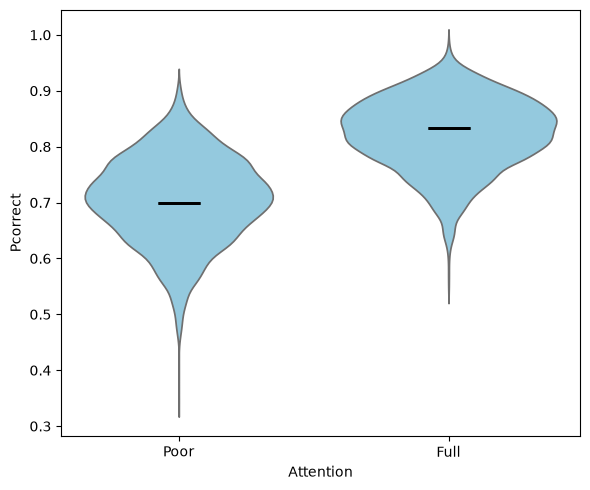

In [42]:
# Plotting with Seaborn and Matplotlib
plt.figure(figsize=(6, 5))

# Violin plot of posterior draws
sns.violinplot(
    data=posterior_pcorrect,
    x="Attention",
    y="Pcorrect",
    inner=None,
    color="skyblue",
)

# Overlay sample mean reference lines using errorbar/scatter
plt.errorbar(
    x=example03_avg["Attention"].astype(str),
    y=example03_avg["Pcorrect"],
    yerr=0,
    fmt="none",
    ecolor="black",
    capsize=15,
    capthick=2,
    linewidth=0,
)

plt.ylabel("Pcorrect")
plt.tight_layout()
plt.show()

Plot posterior distribution for estimated difference in units of probability

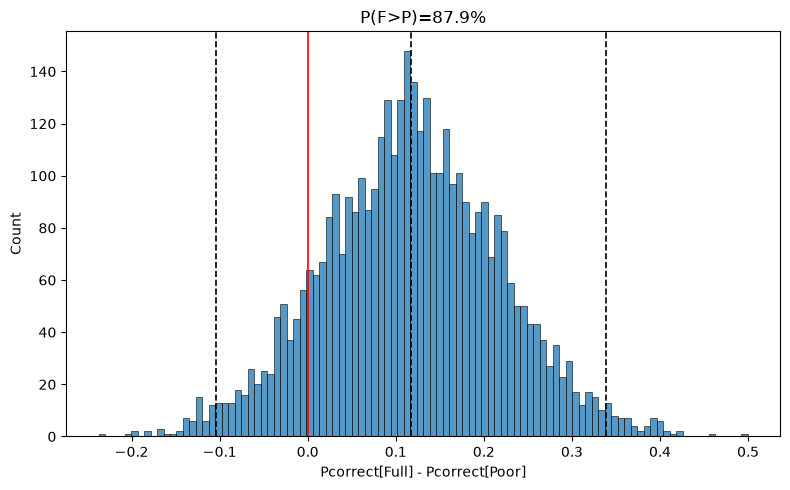

In [44]:
# compute 97% credible interval + median
dA_quantiles = np.quantile(example03_indexing_samples["dA"], [(1 - 0.97) / 2, 0.5, 1 - (1 - 0.97) / 2])

# plot posterior distribution for probability of correct response
plt.figure(figsize=(8, 5))
sns.histplot(example03_indexing_samples["dA"], bins=100, stat="count")
for x in dA_quantiles:
    plt.axvline(x, color="black", linestyle="--", linewidth=1.2)
plt.axvline(0, color="red", linestyle="-", linewidth=1.2)

plt.xlabel("Pcorrect[Full] - Pcorrect[Poor]")
plt.ylabel("Count")
plt.title("P(F>P)=%.1f%%"%(100 * np.mean(example03_indexing_samples['dA'] > 0)))
plt.tight_layout()
plt.show()